<a href="https://colab.research.google.com/github/AruruGunabhiram/attention-enhanced-eczema-severity-classification/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# SETUP — Run this first every time you open a new session
# ============================================================

# Mount Google Drive (to save models)
from google.colab import drive
drive.mount('/content/drive')

# Clone repo
!git clone https://github.com/AruruGunabhiram/attention-enhanced-eczema-severity-classification
%cd attention-enhanced-eczema-severity-classification

# Install dependencies
!pip install -q -r requirements.txt

# Download dataset via kagglehub
import kagglehub
dermnet_path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Dataset path:", dermnet_path)

# Symlink to expected relative path
import os
os.makedirs("data/raw", exist_ok=True)
if not os.path.exists("data/raw/dermnet"):
    os.symlink(dermnet_path, "data/raw/dermnet")
print(" Setup complete")

Mounted at /content/drive
Cloning into 'attention-enhanced-eczema-severity-classification'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 86 (delta 30), reused 81 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 315.51 KiB | 3.29 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/attention-enhanced-eczema-severity-classification
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.5/113.5 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.0 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.1

In [2]:
!pip install -q -r requirements.txt
import kagglehub, os
dermnet_path = kagglehub.dataset_download("shubhamgoel27/dermnet")
os.makedirs("data/raw", exist_ok=True)
if not os.path.exists("data/raw/dermnet"):
    os.symlink(dermnet_path, "data/raw/dermnet")
print("Setup complete")

ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement tensorflow-addons==0.23.0 (from versions: none)
ERROR: No matching distribution found for ten

In [5]:
import sys
sys.path.insert(0, "/content/attention-enhanced-eczema-severity-classification")

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

# ── Keyword → severity mapping ──────────────────────────────────────────────
MILD_KEYWORDS     = ["mild", "patch", "xerotic", "dry", "nummular", "contact"]
SEVERE_KEYWORDS   = ["severe", "infected", "weeping", "crusted", "erythroderma",
                     "inflamed", "acute", "widespread"]

def infer_severity(folder_name: str, file_name: str) -> int:
    """Returns 0=mild, 1=moderate, 2=severe based on keywords."""
    text = (folder_name + " " + file_name).lower()
    if any(k in text for k in SEVERE_KEYWORDS):
        return 2
    if any(k in text for k in MILD_KEYWORDS):
        return 0
    return 1  # default → moderate

# ── Walk DermNet and collect eczema images ───────────────────────────────────
DERMNET_ROOT = "data/raw/dermnet"
ECZEMA_KEYWORDS = ["eczema", "dermatitis", "atopic"]

records = []
for split in ["train", "test"]:
    split_dir = os.path.join(DERMNET_ROOT, split)
    if not os.path.isdir(split_dir):
        continue
    for folder in os.listdir(split_dir):
        folder_lower = folder.lower()
        if not any(k in folder_lower for k in ECZEMA_KEYWORDS):
            continue
        folder_path = os.path.join(split_dir, folder)
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            full_path = os.path.join(folder_path, fname)
            label = infer_severity(folder, fname)
            records.append({"path": full_path, "label": label})

df = pd.DataFrame(records)
print(f"Total eczema images found: {len(df)}")
print(df["label"].value_counts().rename({0:"mild",1:"moderate",2:"severe"}))

Total eczema images found: 2481
label
moderate    1885
mild         469
severe       127
Name: count, dtype: int64


In [7]:
# Oversample mild to reduce imbalance
mild_df     = df[df["label"] == 0]
moderate_df = df[df["label"] == 1]
severe_df   = df[df["label"] == 2]

# Oversample mild up to 150 (or however many exist, whichever is larger)
target_mild = max(150, len(mild_df))
mild_df = mild_df.sample(target_mild, replace=True, random_state=42)

df_balanced = pd.concat([mild_df, moderate_df, severe_df]).sample(frac=1, random_state=42)
print(f"\nAfter oversampling:")
print(df_balanced["label"].value_counts().rename({0:"mild",1:"moderate",2:"severe"}))

# ── 70 / 15 / 15 split ───────────────────────────────────────────────────────
train_df, temp_df = train_test_split(df_balanced, test_size=0.30,
                                     stratify=df_balanced["label"], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                     stratify=temp_df["label"],   random_state=42)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── Save CSVs ─────────────────────────────────────────────────────────────────
os.makedirs("data/stage3", exist_ok=True)
train_df.to_csv("data/stage3/train.csv", index=False)
val_df.to_csv(  "data/stage3/val.csv",   index=False)
test_df.to_csv( "data/stage3/test.csv",  index=False)

print("\nCSVs saved to data/stage3/ ✓")


After oversampling:
label
moderate    1885
mild         469
severe       127
Name: count, dtype: int64

Train: 1736 | Val: 372 | Test: 373

CSVs saved to data/stage3/ ✓


In [8]:
# MobileNetV2 expects preprocess_input → scales [0,255] → [-1, 1]
# Do NOT divide by 255 manually — use preprocess_input instead

IMG_SIZE = 224
BATCH_SIZE = 32
SEVERITY_CLASSES = ["mild", "moderate", "severe"]

def make_mobilenet_dataset(csv_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False):
    import pandas as pd
    df = pd.read_csv(csv_path)
    paths = df["path"].values
    labels = df["label"].values  # 0=mild, 1=moderate, 2=severe

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [image_size, image_size])
        # img is [0,255] here — apply MobileNetV2 preprocessing
        img = preprocess_input(img)  # → [-1, 1]
        return img, label

    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
        # brightness/contrast in [-1,1] space — small deltas are correct here
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.clip_by_value(img, -1.0, 1.0)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Load datasets
train_ds = make_mobilenet_dataset("data/stage3/train.csv", augment=True)
val_ds   = make_mobilenet_dataset("data/stage3/val.csv",   augment=False)
test_ds  = make_mobilenet_dataset("data/stage3/test.csv",  augment=False)

print("Datasets loaded ✓")

Datasets loaded ✓


In [9]:
def build_mobilenetv2_stage3(num_classes=3, dropout_rate=0.4):
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg"  # global average pooling built-in
    )
    base.trainable = False  # freeze base initially

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model

model = build_mobilenetv2_stage3()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

print("Phase 1: Training classification head...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Phase 1: Training classification head...
Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 794ms/step - accuracy: 0.6918 - loss: 0.9077 - val_accuracy: 0.7554 - val_loss: 0.6794 - learning_rate: 0.0010
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.7391 - loss: 0.7101 - val_accuracy: 0.7634 - val_loss: 0.6425 - learning_rate: 0.0010
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.7425 - loss: 0.6727 - val_accuracy: 0.7581 - val_loss: 0.6089 - learning_rate: 0.0010
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7494 - loss: 0.6448 - val_accuracy: 0.7849 - val_loss: 0.6011 - learning_rate: 0.0010
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.7615 - loss: 0.6176 - val_accuracy: 0.7823 - val_loss: 0.5964 - learning_rate: 0.0010
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.7644 - loss: 0.6174 - val_accuracy: 0.7742 - val_loss: 0.5777 - learning_rate: 0.0010
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 132

In [11]:
# Unfreeze top 30 layers of MobileNetV2
model.layers[1].trainable = True  # layers[1] is the base model
for layer in model.layers[1].layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Phase 2: Fine-tuning top 30 layers...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Phase 2: Fine-tuning top 30 layers...
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.7517 - loss: 0.7203 - val_accuracy: 0.7876 - val_loss: 0.5373 - learning_rate: 1.0000e-05
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.7512 - loss: 0.6797 - val_accuracy: 0.7849 - val_loss: 0.5416 - learning_rate: 1.0000e-05
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.7586 - loss: 0.6342 - val_accuracy: 0.7742 - val_loss: 0.5464 - learning_rate: 1.0000e-05
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.7702 - loss: 0.6014 - val_accuracy: 0.7688 - val_loss: 0.5523 - learning_rate: 1.0000e-05
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.7627 - loss: 0.5879 - val_accuracy: 0.7769 - val_loss: 0.5525 - learning_rate: 5.0000e-06
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.7742 - loss: 0.5711 - val_accuracy: 0.7769 - val_loss: 0.5538 - learning_rate: 5.0000e-06
Epoch 7/20
55/55 ━━━━━━━━

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8097 - loss: 0.5238

Test Accuracy: 0.8097 (81.0%)

Classification Report:
              precision    recall  f1-score   support

        mild       0.76      0.39      0.52        71
    moderate       0.82      0.97      0.89       283
      severe       0.00      0.00      0.00        19

    accuracy                           0.81       373
   macro avg       0.52      0.45      0.47       373
weighted avg       0.76      0.81      0.77       373



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


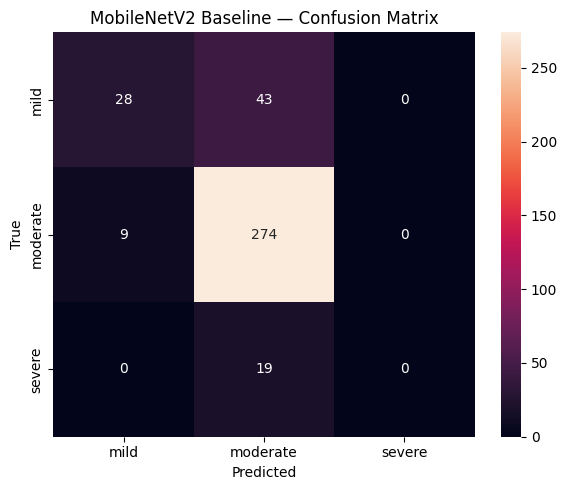

In [12]:
# Test accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

# Macro F1 + per-class report
all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=SEVERITY_CLASSES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=SEVERITY_CLASSES, yticklabels=SEVERITY_CLASSES)
plt.title("MobileNetV2 Baseline — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

In [13]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/eczema_models/stage3_mobilenetv2_baseline.keras"
model.save(save_path)
print(f"Saved → {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved → /content/drive/MyDrive/eczema_models/stage3_mobilenetv2_baseline.keras


In [14]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnetb0_stage3(num_classes=3, dropout_rate=0.4):
    base = EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

effnet_model = build_efficientnetb0_stage3()
effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# EfficientNetB0 expects RAW [0, 255] — do NOT use preprocess_input
# do NOT divide by 255 — that causes class collapse

def make_efficientnet_dataset(csv_path, image_size=IMG_SIZE,
                               batch_size=BATCH_SIZE, augment=False):
    import pandas as pd
    df = pd.read_csv(csv_path)
    paths  = df["path"].values
    labels = df["label"].values

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [image_size, image_size])
        # Keep [0, 255] — EfficientNetB0 handles normalization internally
        return img, label

    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform(
                shape=[], minval=0, maxval=4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=38.0)  # scaled for [0,255]
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

eff_train_ds = make_efficientnet_dataset("data/stage3/train.csv", augment=True)
eff_val_ds   = make_efficientnet_dataset("data/stage3/val.csv")
eff_test_ds  = make_efficientnet_dataset("data/stage3/test.csv")
print("EfficientNet datasets ready ✓")

EfficientNet datasets ready ✓


In [16]:
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

print("Phase 1: Training head...")
history_eff1 = effnet_model.fit(
    eff_train_ds, validation_data=eff_val_ds,
    epochs=25, callbacks=callbacks
)

Phase 1: Training head...
Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 836ms/step - accuracy: 0.7235 - loss: 0.7408 - val_accuracy: 0.7554 - val_loss: 0.6680 - learning_rate: 0.0010
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.7598 - loss: 0.6293 - val_accuracy: 0.7634 - val_loss: 0.6335 - learning_rate: 0.0010
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.7679 - loss: 0.5961 - val_accuracy: 0.7634 - val_loss: 0.6200 - learning_rate: 0.0010
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.7805 - loss: 0.5732 - val_accuracy: 0.7742 - val_loss: 0.5959 - learning_rate: 0.0010
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.7851 - loss: 0.5652 - val_accuracy: 0.7715 - val_loss: 0.5941 - learning_rate: 0.0010
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.7874 - loss: 0.5379 - val_accuracy: 0.7823 - val_loss: 0.5746 - learning_rate: 0.0010
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accurac

In [17]:
effnet_model.layers[1].trainable = True
for layer in effnet_model.layers[1].layers[:-30]:
    layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Phase 2: Fine-tuning...")
history_eff2 = effnet_model.fit(
    eff_train_ds, validation_data=eff_val_ds,
    epochs=20, callbacks=callbacks
)

Phase 2: Fine-tuning...
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 644ms/step - accuracy: 0.5703 - loss: 0.9633 - val_accuracy: 0.8091 - val_loss: 0.5234 - learning_rate: 1.0000e-05
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.6262 - loss: 0.8451 - val_accuracy: 0.8011 - val_loss: 0.5536 - learning_rate: 1.0000e-05
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.6676 - loss: 0.7642 - val_accuracy: 0.7769 - val_loss: 0.5804 - learning_rate: 1.0000e-05
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.7137 - loss: 0.6838 - val_accuracy: 0.7742 - val_loss: 0.6022 - learning_rate: 5.0000e-06
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.7241 - loss: 0.6732 - val_accuracy: 0.7688 - val_loss: 0.6123 - learning_rate: 5.0000e-06
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.7270 - loss: 0.6477 - val_accuracy: 0.7688 - val_loss: 0.6159 - learning_rate: 5.0000e-06
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 902ms/step - accuracy: 0.7989 - loss: 0.4910

Test Accuracy: 79.9%
              precision    recall  f1-score   support

        mild       0.70      0.46      0.56        71
    moderate       0.83      0.93      0.88       283
      severe       0.27      0.16      0.20        19

    accuracy                           0.80       373
   macro avg       0.60      0.52      0.55       373
weighted avg       0.78      0.80      0.78       373



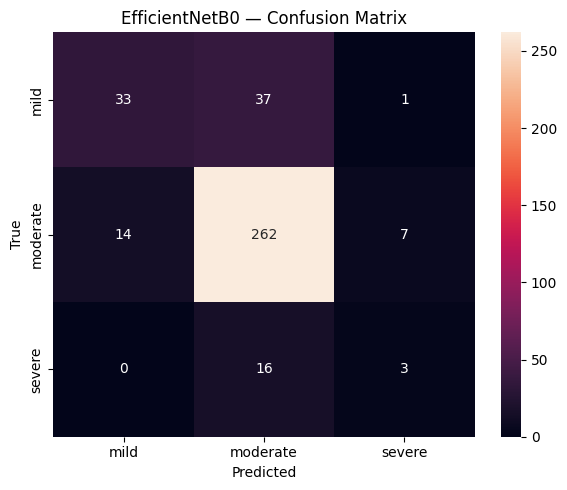

In [18]:
test_loss, test_acc = effnet_model.evaluate(eff_test_ds)
print(f"\nTest Accuracy: {test_acc*100:.1f}%")

all_preds, all_labels = [], []
for images, labels in eff_test_ds:
    preds = effnet_model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=SEVERITY_CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=SEVERITY_CLASSES, yticklabels=SEVERITY_CLASSES)
plt.title("EfficientNetB0 — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

In [19]:
save_path = "/content/drive/MyDrive/eczema_models/stage3_efficientnetb0.keras"
effnet_model.save(save_path)
print(f"Saved → {save_path}")

Saved → /content/drive/MyDrive/eczema_models/stage3_efficientnetb0.keras


Phase 1...
Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 56s 568ms/step - accuracy: 0.7506 - loss: 0.6743 - val_accuracy: 0.7634 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.7673 - loss: 0.6119 - val_accuracy: 0.7634 - val_loss: 0.6492 - learning_rate: 0.0010
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.7805 - loss: 0.5927 - val_accuracy: 0.7688 - val_loss: 0.6357 - learning_rate: 0.0010
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.7782 - loss: 0.5689 - val_accuracy: 0.7769 - val_loss: 0.6107 - learning_rate: 0.0010
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.7921 - loss: 0.5522 - val_accuracy: 0.7823 - val_loss: 0.5810 - learning_rate: 0.0010
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.7978 - loss: 0.5391 - val_accuracy: 0.7876 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.8116 - lo

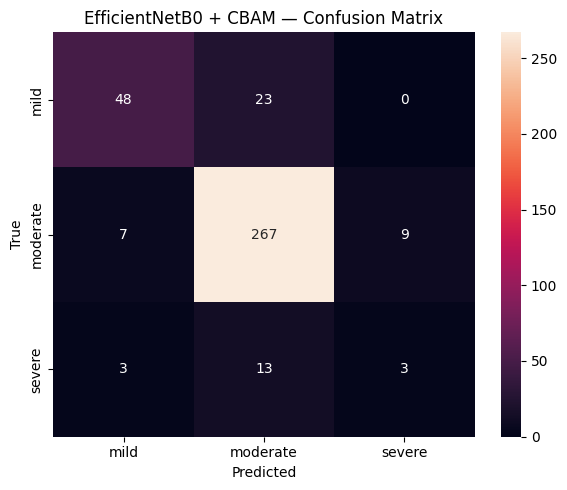

Saved ✓


In [23]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

IMG_SIZE = 224
BATCH_SIZE = 32
SEVERITY_CLASSES = ["mild", "moderate", "severe"]

# ── CBAM blocks (Lambda with output_shape to avoid reload issues) ─────────────
def channel_attention(x, ratio=8):
    channels = int(x.shape[-1])
    avg = layers.GlobalAveragePooling2D()(x)
    mx  = layers.GlobalMaxPooling2D()(x)
    avg = layers.Reshape((1, 1, channels))(avg)
    mx  = layers.Reshape((1, 1, channels))(mx)
    def mlp(t):
        t = layers.Dense(channels // ratio, activation="relu")(t)
        t = layers.Dense(channels)(t)
        return t
    out = layers.Add()([mlp(avg), mlp(mx)])
    out = layers.Activation("sigmoid")(out)
    return layers.Multiply()([x, out])

def spatial_attention(x):
    avg = layers.Lambda(
        lambda t: tf.reduce_mean(t, axis=-1, keepdims=True),
        output_shape=lambda s: tuple(s[:-1]) + (1,)
    )(x)
    mx  = layers.Lambda(
        lambda t: tf.reduce_max(t, axis=-1, keepdims=True),
        output_shape=lambda s: tuple(s[:-1]) + (1,)
    )(x)
    concat = layers.Concatenate()([avg, mx])
    out = layers.Conv2D(1, 7, padding="same", activation="sigmoid")(concat)
    return layers.Multiply()([x, out])

def build_cbam_model(num_classes=3, dropout_rate=0.4):
    base = EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = channel_attention(x)
    x = spatial_attention(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)

# ── Load datasets ─────────────────────────────────────────────────────────────
def make_efficientnet_dataset(csv_path, image_size=IMG_SIZE,
                               batch_size=BATCH_SIZE, augment=False):
    import pandas as pd
    df = pd.read_csv(csv_path)
    paths, labels = df["path"].values, df["label"].values

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [image_size, image_size])
        return img, label

    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=38.0)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_efficientnet_dataset("data/stage3/train.csv", augment=True)
val_ds   = make_efficientnet_dataset("data/stage3/val.csv")
test_ds  = make_efficientnet_dataset("data/stage3/test.csv")

# ── Train ─────────────────────────────────────────────────────────────────────
cbam_model = build_cbam_model()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

cbam_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Phase 1...")
cbam_model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

# Fine-tune
cbam_model.layers[1].trainable = True
for layer in cbam_model.layers[1].layers[:-30]:
    layer.trainable = False
cbam_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Phase 2...")
cbam_model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

# ── Evaluate ──────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_loss, test_acc = cbam_model.evaluate(test_ds)
print(f"\nCBAM Test Accuracy: {test_acc*100:.1f}%")

all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = cbam_model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=SEVERITY_CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=SEVERITY_CLASSES, yticklabels=SEVERITY_CLASSES)
plt.title("EfficientNetB0 + CBAM — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

# ── Save fresh ────────────────────────────────────────────────────────────────
cbam_model.save("/content/drive/MyDrive/eczema_models/stage3_cbam_v2.keras")
print("Saved ✓")

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Custom layers (survive model cloning)
class ReduceMeanChannel(tf.keras.layers.Layer):
    def call(self, x):
        return tf.reduce_mean(x, axis=-1, keepdims=True)
    def compute_output_shape(self, s):
        return tuple(s[:-1]) + (1,)

class ReduceMaxChannel(tf.keras.layers.Layer):
    def call(self, x):
        return tf.reduce_max(x, axis=-1, keepdims=True)
    def compute_output_shape(self, s):
        return tuple(s[:-1]) + (1,)

def channel_attention(x, ratio=8):
    channels = int(x.shape[-1])
    avg = layers.GlobalAveragePooling2D()(x)
    mx  = layers.GlobalMaxPooling2D()(x)
    avg = layers.Reshape((1, 1, channels))(avg)
    mx  = layers.Reshape((1, 1, channels))(mx)
    def mlp(t):
        t = layers.Dense(channels // ratio, activation="relu")(t)
        t = layers.Dense(channels)(t)
        return t
    out = layers.Add()([mlp(avg), mlp(mx)])
    out = layers.Activation("sigmoid")(out)
    return layers.Multiply()([x, out])

def spatial_attention(x):
    avg    = ReduceMeanChannel()(x)
    mx     = ReduceMaxChannel()(x)
    concat = layers.Concatenate()([avg, mx])
    out    = layers.Conv2D(1, 7, padding="same", activation="sigmoid")(concat)
    return layers.Multiply()([x, out])

def build_cbam_model(num_classes=3, dropout_rate=0.4):
    base = EfficientNetB0(input_shape=(224,224,3), include_top=False, weights="imagenet")
    base.trainable = False
    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = channel_attention(x)
    x = spatial_attention(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)

# Train
cbam_model = build_cbam_model()
callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]
cbam_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Phase 1...")
cbam_model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

cbam_model.layers[1].trainable = True
for layer in cbam_model.layers[1].layers[:-30]:
    layer.trainable = False
cbam_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Phase 2...")
cbam_model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

cbam_model.save("/content/drive/MyDrive/eczema_models/stage3_cbam_v3.keras")
print("Saved v3 ✓")

Phase 1...
Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 56s 589ms/step - accuracy: 0.7494 - loss: 0.7447 - val_accuracy: 0.7634 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.7696 - loss: 0.6227 - val_accuracy: 0.7661 - val_loss: 0.6469 - learning_rate: 0.0010
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.7753 - loss: 0.6124 - val_accuracy: 0.7688 - val_loss: 0.6380 - learning_rate: 0.0010
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.7707 - loss: 0.6002 - val_accuracy: 0.7688 - val_loss: 0.6243 - learning_rate: 0.0010
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.7811 - loss: 0.5775 - val_accuracy: 0.7769 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.7702 - loss: 0.5762 - val_accuracy: 0.7742 - val_loss: 0.5985 - learning_rate: 0.0010
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.7817 - lo

In [5]:
# ── Rebuild symlink + CSVs after runtime reset ────────────────────────────────
import kagglehub, os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

# Symlink
dermnet_path = kagglehub.dataset_download("shubhamgoel27/dermnet")
os.makedirs("data/raw", exist_ok=True)
if not os.path.exists("data/raw/dermnet"):
    os.symlink(dermnet_path, "data/raw/dermnet")
print("Symlink ready ✓")

# Rebuild CSVs
MILD_KEYWORDS   = ["mild","patch","xerotic","dry","nummular","contact"]
SEVERE_KEYWORDS = ["severe","infected","weeping","crusted","erythroderma",
                   "inflamed","acute","widespread"]
ECZEMA_KEYWORDS = ["eczema","dermatitis","atopic"]

def infer_severity(folder, fname):
    text = (folder + " " + fname).lower()
    if any(k in text for k in SEVERE_KEYWORDS): return 2
    if any(k in text for k in MILD_KEYWORDS):   return 0
    return 1

records = []
for split in ["train", "test"]:
    split_dir = os.path.join("data/raw/dermnet", split)
    if not os.path.isdir(split_dir): continue
    for folder in os.listdir(split_dir):
        if not any(k in folder.lower() for k in ECZEMA_KEYWORDS): continue
        folder_path = os.path.join(split_dir, folder)
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".jpg",".jpeg",".png")): continue
            records.append({"path": os.path.join(folder_path, fname),
                            "label": infer_severity(folder, fname)})

df = pd.DataFrame(records)
mild_df     = df[df["label"]==0].sample(max(150, len(df[df["label"]==0])),
                                         replace=True, random_state=42)
moderate_df = df[df["label"]==1]
severe_df   = df[df["label"]==2]
df_bal = pd.concat([mild_df, moderate_df, severe_df]).sample(frac=1, random_state=42)

train_df, temp_df = train_test_split(df_bal, test_size=0.30,
                                      stratify=df_bal["label"], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                      stratify=temp_df["label"], random_state=42)

os.makedirs("data/stage3", exist_ok=True)
train_df.to_csv("data/stage3/train.csv", index=False)
val_df.to_csv(  "data/stage3/val.csv",   index=False)
test_df.to_csv( "data/stage3/test.csv",  index=False)
print(f"CSVs rebuilt ✓  (train={len(train_df)}, val={len(val_df)}, test={len(test_df)})")

Using Colab cache for faster access to the 'dermnet' dataset.
Symlink ready ✓
CSVs rebuilt ✓  (train=1736, val=372, test=373)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded ✓
test_ds ready ✓
Got samples for classes: [1, 0, 2]


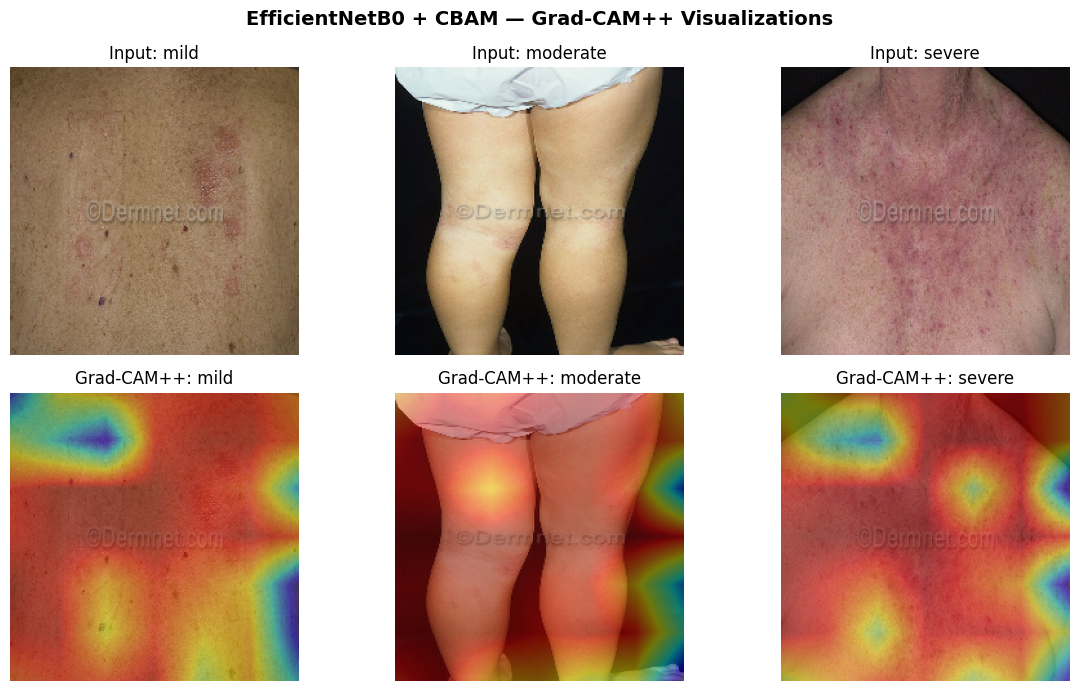

Saved gradcam_cbam.png ✓


In [6]:
# ── Step 1: Reload model from Drive ──────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
import numpy as np

# Must redefine custom layers before loading
class ReduceMeanChannel(tf.keras.layers.Layer):
    def call(self, x):
        return tf.reduce_mean(x, axis=-1, keepdims=True)

class ReduceMaxChannel(tf.keras.layers.Layer):
    def call(self, x):
        return tf.reduce_max(x, axis=-1, keepdims=True)

from google.colab import drive
drive.mount('/content/drive')

cbam_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/eczema_models/stage3_cbam_v3.keras",
    custom_objects={
        "ReduceMeanChannel": ReduceMeanChannel,
        "ReduceMaxChannel":  ReduceMaxChannel
    },
    compile=False
)
cbam_model.compile(optimizer="adam",
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
print("Model loaded ✓")

# ── Step 2: Rebuild test_ds ───────────────────────────────────────────────────
IMG_SIZE, BATCH_SIZE = 224, 32

def make_efficientnet_dataset(csv_path, image_size=IMG_SIZE,
                               batch_size=BATCH_SIZE, augment=False):
    import pandas as pd
    df = pd.read_csv(csv_path)
    paths, labels = df["path"].values, df["label"].values
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [image_size, image_size])
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = make_efficientnet_dataset("data/stage3/test.csv")
print("test_ds ready ✓")

# ── Step 3: Grad-CAM++ ────────────────────────────────────────────────────────
!pip install -q tf-keras-vis
import matplotlib.pyplot as plt
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

SEVERITY_CLASSES = ["mild", "moderate", "severe"]

def get_sample_per_class(model, ds, n_classes=3):
    samples = {}
    for images, labels in ds:
        preds = np.argmax(model.predict(images, verbose=0), axis=1)
        for i in range(len(labels)):
            c = int(labels[i])
            if c not in samples and preds[i] == c:
                samples[c] = images[i].numpy()
            if len(samples) == n_classes:
                return samples
    return samples

samples = get_sample_per_class(cbam_model, test_ds)
print(f"Got samples for classes: {list(samples.keys())}")

gradcam = GradcamPlusPlus(cbam_model, model_modifier=ReplaceToLinear(), clone=True)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for cls_idx in range(3):
    img       = samples[cls_idx]
    img_batch = np.expand_dims(img, 0)
    cam       = gradcam(CategoricalScore([cls_idx]), img_batch, penultimate_layer=-1)[0]
    display   = img / 255.0

    axes[0, cls_idx].imshow(display)
    axes[0, cls_idx].set_title(f"Input: {SEVERITY_CLASSES[cls_idx]}", fontsize=12)
    axes[0, cls_idx].axis("off")

    axes[1, cls_idx].imshow(display)
    axes[1, cls_idx].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, cls_idx].set_title(f"Grad-CAM++: {SEVERITY_CLASSES[cls_idx]}", fontsize=12)
    axes[1, cls_idx].axis("off")

plt.suptitle("EfficientNetB0 + CBAM — Grad-CAM++ Visualizations",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gradcam_cbam.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved gradcam_cbam.png ✓")